In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [2]:
df = pd.read_csv("customer_churn.csv")
df.head()
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


In [3]:
le = LabelEncoder()

categorical_cols = ['Contract','PaymentMethod','PaperlessBilling']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

In [4]:
X = df.drop(columns=['Churn'])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

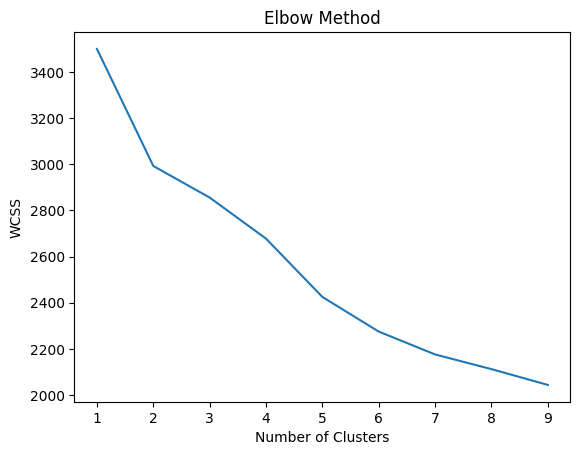

In [5]:
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Segment'] = kmeans.fit_predict(X_scaled)

df['Segment'].value_counts()

Segment
1    180
0    177
2    143
Name: count, dtype: int64

In [7]:
hierarchical = AgglomerativeClustering(n_clusters=3)

df['Hierarchical_Segment'] = hierarchical.fit_predict(X_scaled)

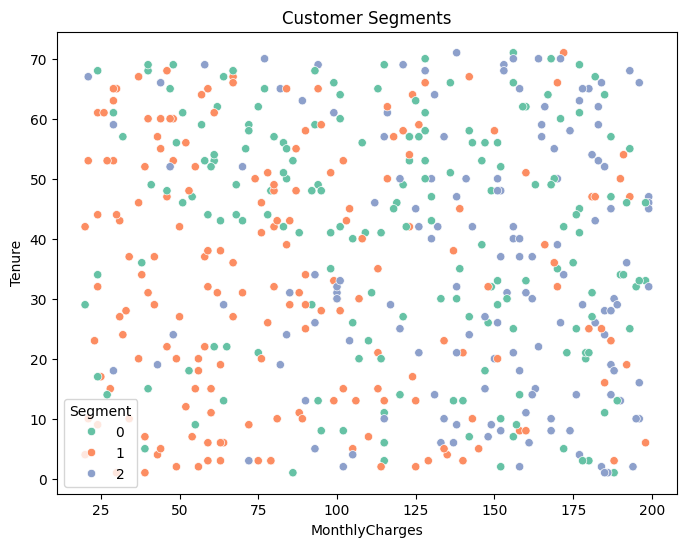

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['MonthlyCharges'],
    y=df['Tenure'],
    hue=df['Segment'],
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

In [9]:
segment_profiles = df.groupby("Segment").mean()

segment_profiles

,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Hierarchical_Segment
Segment,,,,,,,,,
0,40.700565,117.920904,3762.627119,0.870056,0.197740,0.644068,0.446328,0.067797,1.146893
1,33.222222,85.650000,4591.727778,0.911111,1.300000,0.200000,0.800000,0.111111,0.477778
2,35.538462,143.559441,4380.734266,1.090909,1.643357,0.650350,0.181818,0.146853,0.986014


Segment: 1
Accuracy: 0.9722222222222222
Precision: 1.0
Recall: 0.75
F1 Score: 0.8571428571428571


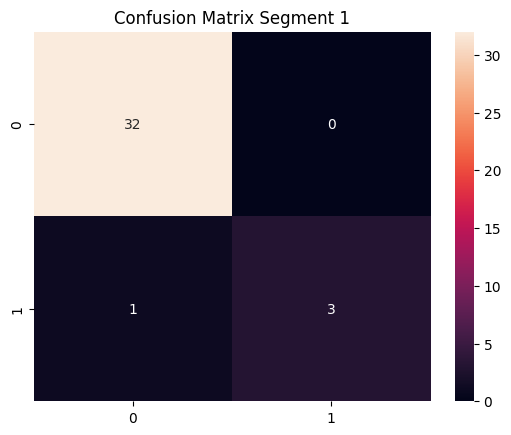

Segment: 0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


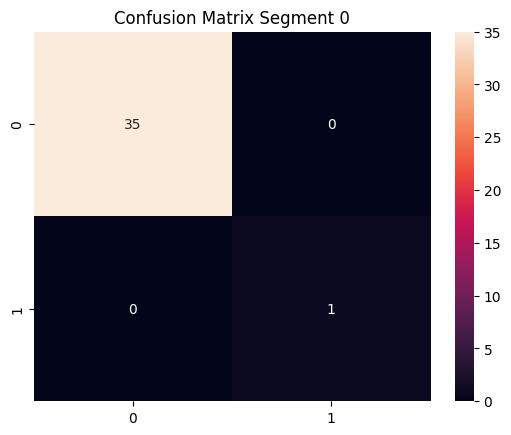

Segment: 2
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


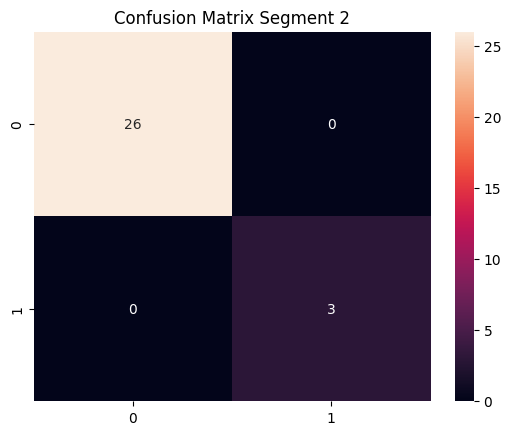

In [10]:
results = []
segments = df['Segment'].unique()

for segment in segments:
    
    segment_data = df[df['Segment']==segment]
    
    X = segment_data.drop(columns=['Churn','Segment','Hierarchical_Segment'])
    y = segment_data['Churn']
    
    if len(segment_data) < 20:
        continue
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,y,test_size=0.2,random_state=42
    )
    
    rf = RandomForestClassifier(random_state=42)
    
    rf.fit(X_train,y_train)
    
    predictions = rf.predict(X_test)
    
    acc = accuracy_score(y_test,predictions)
    prec = precision_score(y_test,predictions)
    rec = recall_score(y_test,predictions)
    f1 = f1_score(y_test,predictions)
    
    try:
        roc = roc_auc_score(y_test,predictions)
    except:
        roc = 0
    
    results.append([segment,acc,prec,rec,f1,roc])
    
    print("Segment:",segment)
    print("Accuracy:",acc)
    print("Precision:",prec)
    print("Recall:",rec)
    print("F1 Score:",f1)
    
    cm = confusion_matrix(y_test,predictions)
    
    sns.heatmap(cm,annot=True,fmt="d")
    plt.title(f"Confusion Matrix Segment {segment}")
    plt.show()

In [11]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print("Best Parameters:",grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


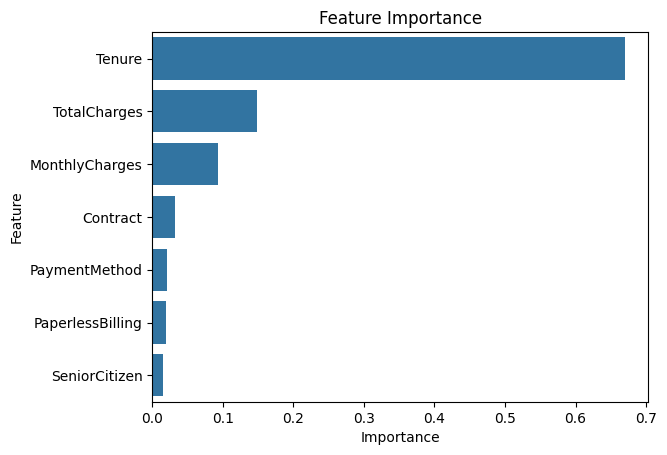

In [12]:
importances = best_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature":features,
    "Importance":importances
}).sort_values(by="Importance",ascending=False)

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")
plt.show()

In [13]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Segment",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df
results_df.to_csv("model_evaluation_results.csv",index=False)

In [14]:
for seg in df['Segment'].unique():
    
    avg_charge = df[df['Segment']==seg]['MonthlyCharges'].mean()
    
    print(f"\nSegment {seg}")
    
    if avg_charge > 70:
        print("Premium segment → Offer loyalty rewards and premium services")
    
    elif avg_charge > 40:
        print("Medium segment → Offer bundled plans and discounts")
    
    else:
        print("Budget segment → Offer affordable plans to reduce churn")


Segment 1
Premium segment → Offer loyalty rewards and premium services

Segment 0
Premium segment → Offer loyalty rewards and premium services

Segment 2
Premium segment → Offer loyalty rewards and premium services
